
# CADERNO DE EXERCICIOS - Analise de Dados com Pandas e Seaborn
 Base de dados: modafina_vendas.csv (loja ficticia de roupas)
# Como usar:
   - Coloque o arquivo modafina_vendas.csv na pasta data.
  - Leia a instrucao de cada celula e escreva seu codigo logo abaixo dela.


In [1]:
# Exercicio 1
# Importe as bibliotecas pandas e seaborn e configure o tema visual dos graficos.
import pandas as pd 
import seaborn as sns
sns.set_theme(style="whitegrid")

In [5]:
# Exercicio 2
# Carregue o arquivo modafina_vendas.csv em um DataFrame
# e mostre as primeiras linhas para conhecer os dados.
df = pd.read_csv(r"..\data\dataset_aula02_exercicio_modafina.csv")
df.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [6]:
# Exercicio 3
# Mostre quantas linhas e quantas colunas a base de dados possui.
df.shape

(700, 8)

In [7]:
# Exercicio 4
# Mostre as informacoes gerais da base: o nome das colunas,
# o tipo de cada uma e a quantidade de valores nao nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data_venda         700 non-null    object 
 1   categoria_produto  700 non-null    object 
 2   tamanho            700 non-null    object 
 3   preco              700 non-null    float64
 4   quantidade         700 non-null    int64  
 5   estado             700 non-null    object 
 6   forma_pagamento    700 non-null    object 
 7   nota_avaliacao     700 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 43.9+ KB


In [8]:
# Exercicio 5
# Crie uma nova coluna chamada faturamento, multiplicando o preco
# pela quantidade de cada venda. Depois, mostre as primeiras linhas.
df["faturamento"] = df["preco"] * df["quantidade"]
df.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [19]:
# Exercicio 6
# Calcule o faturamento total da loja (a soma da coluna faturamento).
# Em seguida, exiba esse valor formatado como moeda brasileira,
# no formato R$ 0.000,00 (exemplo: R$ 232.687,92).
faturamento_total = df["faturamento"].sum()

faturamento_formatado = f"{faturamento_total:,.2f}".replace(",","x").replace(".",",").replace("x",".")
faturamento_formatado


'232.687,92'

In [20]:
# Exercicio 7
# Descubra quantos pedidos existem de cada categoria de produto.
df["categoria_produto"].value_counts()


categoria_produto
Camisetas     191
Calças        153
Vestidos      137
Calçados      118
Acessórios    101
Name: count, dtype: int64

In [ ]:
# Exercicio 8
# Descubra quanto cada categoria de produto faturou no total,
# ordenando da que mais faturou para a que menos faturou.
df.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=False)

categoria_produto
Calçados      67848.29
Vestidos      63743.92
Calças        51954.17
Camisetas     31637.03
Acessórios    17504.51
Name: faturamento, dtype: float64

In [26]:
def converter_moedas(valor):
    return f"{valor:,.2f}".replace(",","x").replace(".",",").replace("x",".")

faturamento_por_categoria = df.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=False)
faturamento_por_categoria.map(converter_moedas)


categoria_produto
Calçados      67.848,29
Vestidos      63.743,92
Calças        51.954,17
Camisetas     31.637,03
Acessórios    17.504,51
Name: faturamento, dtype: object

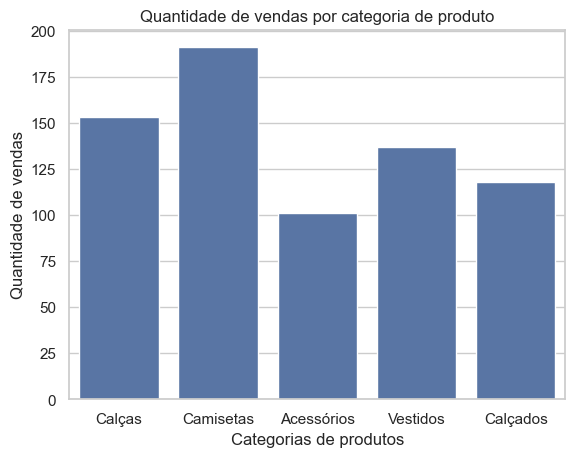

In [33]:
# Exercicio 9
# Crie um grafico que mostre a quantidade de pedidos por categoria de produto.
# Coloque um titulo no grafico e nomes nos eixos.
grafico = sns.countplot(data=df,x="categoria_produto");
grafico.set_title("Quantidade de vendas por categoria de produto");
grafico.set_xlabel("Categorias de produtos");
grafico.set_ylabel("Quantidade de vendas");


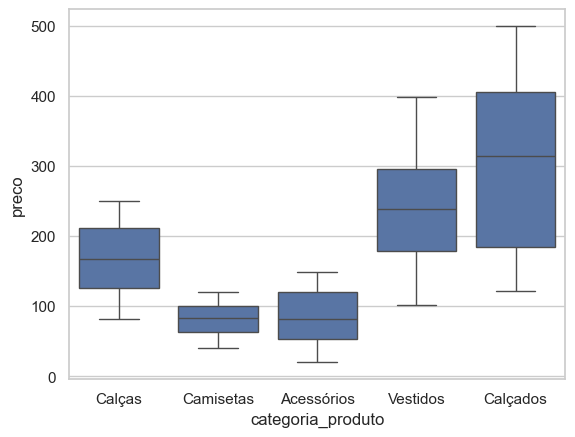

In [37]:
# Exercicio 10
# Crie um grafico que compare a distribuicao do preco entre as
# diferentes categorias de produto. Coloque um titulo no grafico.
grafico = sns.boxplot(data=df,x="categoria_produto",y="preco")


Text(0, 0.5, 'Contagem')

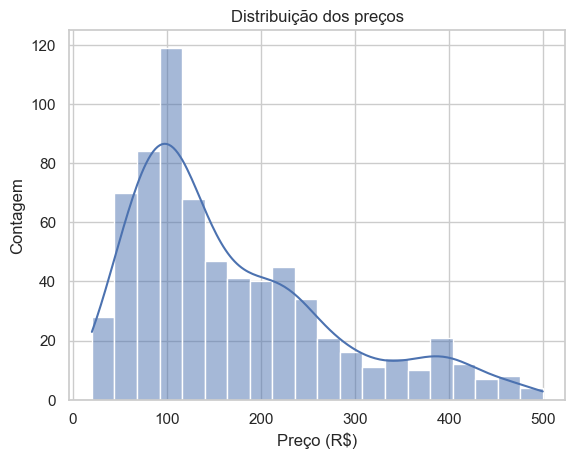

In [ ]:
# Exercicio 11
# Crie um grafico que mostre a distribuicao dos precos dos produtos.
# Coloque um titulo no grafico.
